Script to run inference on our RDM models 

In [29]:
#append_str = '_stickfunction'
#append_str = '_stickfunction5'
append_str = '_stickfunction5vis'
#append_str = '_boxcar5vis'

aff_mag_exclusion = False

In [30]:
regions = ['Entorhinal-bilateral', 'Entorhinal-right', 'Hippocampus-bilateral', 'OFC-bilateral', 'SPL-bilateral', 
        '1.0-bilateral', 'pACC-bilateral', 'Area_4a-bilateral', 'hoc1_hoc2-bilateral'] #rel5Entorhinal-bilateral 'hoc1_hoc2-bilateral', 

#regions = ['hoc1_hoc2-bilateral']
# 1.0 is primary auditory cortex, hoc1_hoc2, Area_4a is premotor cortex, hoc1_hoc2 is primary and secondary visual cortex
models = ['affordance', 'affordance_magnitude', 'link_distance']

regions = ['Entorhinal-bilateral', 'Entorhinal-right', 'rel2Entorhinal-right', 'PhG-bilateral', 'PhG-left', 'OFC-bilateral', 'pACC-bilateral',
           'Hippocampus-bilateral', 'Hippocampus-left', 'Hippocampus-right', '1.0-bilateral', 'Area_4a-bilateral', 'hoc1_hoc2-bilateral']

regions = ['7A-left', '7A-right', '5L-right', '5M-right']

regions = ['Entorhinal-bilateral', 'Entorhinal-right', 'pACC-bilateral', 'Hippocampus-bilateral', 'OFC-bilateral']
regions = ['7A-bilateral']
regions = ['Entorhinal-right', 'pACC-bilateral', 'Hippocampus-bilateral', 'OFC-bilateral', '7A-bilateral']
regions = ['Entorhinal-left', 'Entorhinal-right']
models = ['affordance']
regions = ['Entorhinal-left']


In [31]:
import sys
sys.path.append('/data/u_eperon_software/python/debian-bullseye-amd64/lib/python3.9/site-packages') # in case the environment did not load properly

import os
from glob import glob

import rsatoolbox
import rsatoolbox.data as rsd # abbreviation to deal with dataset
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns
import nilearn
import nibabel as nib
from nilearn.masking import apply_mask
import rsatoolbox.rdm as rsr
import json
from scipy.stats import spearmanr
import pandas as pd
import scipy
from scipy.stats import ttest_1samp, pearsonr, spearmanr




# =============================================================================
# 2. Set up parameters and paths
# =============================================================================

glm_results_dir = '/data/pt_02747/action_hippo/data/derivatives/first_level/nilearn_glm_runwise/'


subs = [os.path.basename(f) for f in glob(glm_results_dir + 'sub*')]
#subs = ["sub-39"]

subs.sort()

sub_ids = [sub[-2:] for sub in subs if '.' not in sub]

# code for subset of subs before vxelrel selection is done
#subs_final = []
#for sub_ in subs:
#    rdm_file = glm_results_dir + f'{sub_}/{sub_}_rel5Entorhinal-bilateral_rdm_crossnobis.pkl'
#    # if file exists load, otherwise continue
#    if os.path.isfile(rdm_file):
#        subs_final.append(sub_)

#subs = subs_final


# load performance dictionary
model_path = '/data/pt_02747/action_hippo/code/extras/'
performance_file = 'subject_performances.json'
with open(os.path.join(model_path, performance_file), 'r') as f:
    performance_dict = json.load(f)


subs


['sub-01',
 'sub-03',
 'sub-04',
 'sub-05',
 'sub-06',
 'sub-07',
 'sub-08',
 'sub-09',
 'sub-10',
 'sub-11',
 'sub-12',
 'sub-13',
 'sub-14',
 'sub-15',
 'sub-16',
 'sub-17',
 'sub-19',
 'sub-21',
 'sub-22',
 'sub-23',
 'sub-24',
 'sub-25',
 'sub-26',
 'sub-27',
 'sub-28',
 'sub-29',
 'sub-30',
 'sub-31',
 'sub-32',
 'sub-34',
 'sub-35',
 'sub-36',
 'sub-37',
 'sub-38',
 'sub-39',
 'sub-40',
 'sub-41',
 'sub-42',
 'sub-43',
 'sub-45',
 'sub-46',
 'sub-47',
 'sub-48',
 'sub-49',
 'sub-50',
 'sub-51',
 'sub-52',
 'sub-53',
 'sub-54',
 'sub-55',
 'sub-56',
 'sub-57',
 'sub-58',
 'sub-59',
 'sub-60',
 'sub-61',
 'sub-62']

In [32]:
# =============================================================================
# function to retrieve neural rdms from a previous analysis
# =============================================================================

def get_neural_rdms(subs_, region_, glm_results_dir=glm_results_dir, append_str=append_str):
    rdms_list = []

    for sub_ in subs_:
        rdm_file = glm_results_dir + f'{sub_}/{sub_}{append_str}_{region_}_rdm_crossnobis.pkl'
        rdm = rsr.load_rdm(rdm_file)
        rdms_list.append(rdm)

    rdms = rsr.concat(rdms_list)

    #print('number of subjects: ', len(subs_))
    #print('number of rdms: ', len(rdms.dissimilarities))

    if rdms.rdm_descriptors['subj'] != subs_:
        print('ERROR: rdms and subjects do not match')
        # stop the code
        raise ValueError('rdms and subjects do not match')
    else:
        #print('rdms and subjects match')
        return rdms

# =============================================================================
# function to get spearman tau correlations between neural and behavioral rdms
# =============================================================================


def compare_rho_a(vector1, vector2):
    """calculates the spearman rank correlations between
    two RDMs objects without tie correction

    Args:
        v1, v2 (numpy.ndarray): RDMs to be compared
    Returns:
        numpy.ndarray: dist:
            rank correlations between the two RDMs

    """

    # check input is np array and if not, make it one
    if type(vector1) is not np.ndarray:
        vector1 = np.array(vector1)
    if type(vector2) is not np.ndarray:
        vector2 = np.array(vector2)

    # check input is 2D and if not, make it one
    if len(vector1.shape) != 2:
        vector1 = np.atleast_2d(vector1)
    if len(vector2.shape) != 2:
        vector2 = np.atleast_2d(vector2)


    # check input is horizontal and if not, make it one
    if vector1.shape[0] > vector1.shape[1]:
        vector1 = vector1.T
    if vector2.shape[0] > vector2.shape[1]:
        vector2 = vector2.T
        
    vector1 = np.apply_along_axis(scipy.stats.rankdata, 1, vector1)
    vector2 = np.apply_along_axis(scipy.stats.rankdata, 1, vector2)
    vector1 = vector1 - np.mean(vector1, 1, keepdims=True)
    vector2 = vector2 - np.mean(vector2, 1, keepdims=True)
    n = vector1.shape[1]
    sim = np.einsum('ij,kj->ik', vector1, vector2) / (n ** 3 - n) * 12
    return sim[0][0]


# =============================================================================
# function to run partial correlation using rho-a
# =============================================================================

def partial_corr_rho_a(x, y, covar):
    """
    Compute the partial correlation coefficient between two variables (x and y)
    while controlling for the effects of other variables (covar) using rho-a correlation.

    Parameters:
    - x, y: variables as list
    - covar: list of covariates (list of lists).

    Returns:
    - r: Partial correlation coefficient between x and y controlling for covar.
    """

    # Compute rho-a correlation between x and y
    r_xy = compare_rho_a(x, y)

    # Compute rho-a correlations between x, y, and covariates
    r_x_covar = [compare_rho_a(x, cov) for cov in covar]
    r_y_covar = [compare_rho_a(y, cov) for cov in covar]

    # Compute the partial correlation coefficient
    numerator = r_xy - np.dot(r_x_covar, r_y_covar)
    denominator = np.sqrt((1 - np.sum(np.square(r_x_covar))) * (1 - np.sum(np.square(r_y_covar))))
    r = numerator / denominator

    return r





# =============================================================================
# function to retrieve behavioral rdms from a previous analysis
# =============================================================================

def get_behav_rdm_correlations(subs_, rdms, model_name='behav_affordance'):
    all_models_corr = [] # correlations between neural and behavioral rdms
    rdms_behav = [] # behavioral rdms
    ind = 0
    for sub_ in subs_:
        print(sub_)
        # get behav_affordance model
        model_dir = '/data/pt_02747/action_hippo/data/derivatives/first_level/models/'
        model_file = f"{sub_}_model_dictionaries.json"
        with open(model_dir + model_file) as f:
            models = json.load(f)
        model = models[model_name]
        rdm_ = rsatoolbox.rdm.RDMs(np.array([[[model['11'], model['12'], model['13'], model['14']],
                                                    [model['12'], model['22'], model['23'], model['24']],
                                                    [model['13'], model['23'], model['33'], model['34']],
                                                    [model['14'], model['24'], model['34'], model['44']]]]),
                                dissimilarity_measure='KL_divergence'
                            )

        behav_rdm = rdm_.dissimilarities[0]
        print('model rdm:', behav_rdm)
        subject_rdm = rdms.dissimilarities[ind]
        print('neural rdm:', subject_rdm)
        if model == 'behav_affordance':
            all_models_corr.append(pearsonr(subject_rdm, behav_rdm)[0])
        else:
            all_models_corr.append(compare_rho_a(subject_rdm, behav_rdm))
        rdms_behav.append(rdm_)
        ind += 1

    return rdms_behav, all_models_corr


from rsatoolbox.inference import eval_fixed
from rsatoolbox.inference.evaluate import fisher_transform_results
def get_behav_rdm_correlations_new(subs_, rdms, 
                                    aff_mag_exclusion = aff_mag_exclusion,
                                    model_name='behav_affordance', 
                                    model_dir = '/data/pt_02747/action_hippo/data/derivatives/first_level/models/'):
    all_models_corr = [] # correlations between neural and behavioral rdms
    rdms_behav = [] # behavioral rdms
    ind = 0
    model_dir = '/data/pt_02747/action_hippo/data/derivatives/first_level/models/'

    for sub_ in subs_:

        # if model is not affordance_magnitude or link distance
        if model_name != 'affordance_magnitude' and model_name != 'link_distance':
            print(sub_)
            # get rdm for this subject
            rdm_sub = rdms.subsample('subj', sub_)
            print('sub rdm:', rdm_sub.dissimilarities)
            # get behav_affordance model
            model_file = f"{sub_}_model_dictionaries.json"
            with open(model_dir + model_file) as f:
                models = json.load(f)
            model = models[model_name]
            model_diss = rsatoolbox.rdm.RDMs(np.array([[[model['11'], model['12'], model['13'], model['14']],
                                                            [model['12'], model['22'], model['23'], model['24']],
                                                            [model['13'], model['23'], model['33'], model['34']],
                                                            [model['14'], model['24'], model['34'], model['44']]]]),
                                        dissimilarity_measure='count',
                                        descriptors={'n_rdm': 1}
                                    )
            print('model rdm:', model_diss.dissimilarities)

            # create model as fixed model for evaluation
            rdm_model = rsatoolbox.model.ModelFixed(model_name, model_diss)
            rdm_model.n_rdm = 1

            print(rdm_model)
            # evaluate model

            if model_name == 'behav_affordance':
                comp_str = 'corr'
                eval_results = eval_fixed(rdm_model, rdm_sub, method='corr')
            else:
                eval_results = eval_fixed(rdm_model, rdm_sub, method='rho-a') #rho-a
                comp_str = 'rho-a'

            eval_results = fisher_transform_results(eval_results)

            print(eval_results)
            print(eval_results.evaluations)

            eval_score = eval_results.evaluations[0][0][0] #because we only have one model and one rdm, so essentially only one evaluation
            
        else:
            print('USING PARTIAL CORRELATION')
            print(sub_)
            # get rdm for this subject
            rdm_sub = rdms.subsample('subj', sub_)
            print('sub rdm:', rdm_sub.dissimilarities)
            # get behav_affordance model
            model_file = f"{sub_}_model_dictionaries.json"
            with open(model_dir + model_file) as f:
                models = json.load(f)
            model_affmag = models['affordance_magnitude']
            model_linkdist = models['link_distance']
            model_diss_affmag = rsatoolbox.rdm.RDMs(np.array([[[model_affmag['11'], model_affmag['12'], model_affmag['13'], model_affmag['14']],
                                                            [model_affmag['12'], model_affmag['22'], model_affmag['23'], model_affmag['24']],
                                                            [model_affmag['13'], model_affmag['23'], model_affmag['33'], model_affmag['34']],
                                                            [model_affmag['14'], model_affmag['24'], model_affmag['34'], model_affmag['44']]]]),
                                        dissimilarity_measure='count',
                                        descriptors={'n_rdm': 1}
                                    )
            model_diss_affmag_tmp = model_diss_affmag.dissimilarities[0]

            model_diss_linkdist = rsatoolbox.rdm.RDMs(np.array([[[model_linkdist['11'], model_linkdist['12'], model_linkdist['13'], model_linkdist['14']],
                                                            [model_linkdist['12'], model_linkdist['22'], model_linkdist['23'], model_linkdist['24']],
                                                            [model_linkdist['13'], model_linkdist['23'], model_linkdist['33'], model_linkdist['34']],
                                                            [model_linkdist['14'], model_linkdist['24'], model_linkdist['34'], model_linkdist['44']]]]),
                                        dissimilarity_measure='count',
                                        descriptors={'n_rdm': 1}
                                    )
            model_diss_linkdist_tmp = model_diss_linkdist.dissimilarities[0]

            neural_diss_tmp = rdm_sub.dissimilarities[0]

            if model_name == 'affordance_magnitude':
                eval_corr = partial_corr_rho_a(neural_diss_tmp, model_diss_affmag_tmp, [model_diss_linkdist_tmp])
                model_diss = model_diss_affmag
            elif model_name == 'link_distance':
                eval_corr = partial_corr_rho_a(neural_diss_tmp, model_diss_linkdist_tmp, [model_diss_affmag_tmp])
                model_diss = model_diss_linkdist
            
            # if 1 or -1, replace with 0.999 or -0.999
            if eval_corr == 1:
                eval_corr = 0.999
            elif eval_corr == -1:
                eval_corr = -0.999

            eval_score = np.arctanh(eval_corr) # z-score

        # =============================================================================
        if aff_mag_exclusion:
            # exclude first and last elements of dissimilarities list 
            # this avoids any correlations with link distance, but means correlation of 4x4 list so is generally less good

            diss_neural_tmp = rdm_sub.dissimilarities[0][1:-1]
            print('sub rdm reduced:', diss_neural_tmp)
            diss_model_tmp = model_diss.dissimilarities[0][1:-1]
            print('model rdm reduced:', diss_model_tmp)

            eval_corr = compare_rho_a(diss_neural_tmp, diss_model_tmp)

            # if 1 or -1, replace with 0.999 or -0.999
            if eval_corr == 1:
                eval_corr = 0.999
            elif eval_corr == -1:
                eval_corr = -0.999

            eval_score = np.arctanh(eval_corr) # z-score
        
        # =============================================================================

        rdms_behav.append(model_diss)
        ind += 1
        all_models_corr.append(eval_score)
        #all_models_corr.append(np.sqrt((57-3) / 1.06) * np.arctanh(eval_score)) 
        #not sure if this is necessary, probably not as rsatoolbox doesn't do it

    return rdms_behav, all_models_corr




In [33]:

# empty list to add data to
data_ = []

for model_ in models:
    for region_ in regions:
        rdms = get_neural_rdms(subs, region_)

        # add find average rdm value for each subject - this way we can see SNR later
        avg_dist = []
        for i in range(len(rdms.dissimilarities)):
            avg_dist.append([np.mean(rdms.dissimilarities[i]), rdms.dissimilarities[i][3]]) #fourth item is 2-3 difference, as rdm reads vertically
            

        rdms_behav, all_models_corr = get_behav_rdm_correlations_new(subs, rdms, model_name=model_)

        
        # add results to dataframe
        for i in range(len(subs)):
            data_.append([subs[i], model_, region_, all_models_corr[i], performance_dict[subs[i]], avg_dist[i][0], avg_dist[i][1]])
        
# make data into dataframe
df = pd.DataFrame(data_, columns=['sub', 'model', 'region', 'correlation', 'performance', 'mean_rdm_value', '32_rdm_value'])

sub-01
sub rdm: [[-62.87515109  26.77474373 -24.53039662  52.20088203  14.37310926
   62.58991943]]
model rdm: [[1. 1. 0. 2. 1. 1.]]
Results for running fixed evaluation for rho-a on 1 models:

Model      |   Eval ± SEM   | p (against 0) | p (against NC) |
--------------------------------------------------------------
affordance |  0.458 ±  nan |          nan  |           nan  |

p-values are based on uncorrected t-tests
[[[0.45814537]]]
sub-03
sub rdm: [[ -0.3459796  -49.80737093  -7.14892511 -11.59540373   1.63813816
  -50.68345916]]
model rdm: [[1. 1. 0. 2. 1. 1.]]
Results for running fixed evaluation for rho-a on 1 models:

Model      |   Eval ± SEM   | p (against 0) | p (against NC) |
--------------------------------------------------------------
affordance | -0.144 ±  nan |          nan  |           nan  |

p-values are based on uncorrected t-tests
[[[-0.14384104]]]
sub-04
sub rdm: [[-54.09042685  19.40016907  20.6110009  -12.33080564  74.14720813
  -69.60605794]]
model rdm: [[1.

In [6]:
region_

'Entorhinal-left'

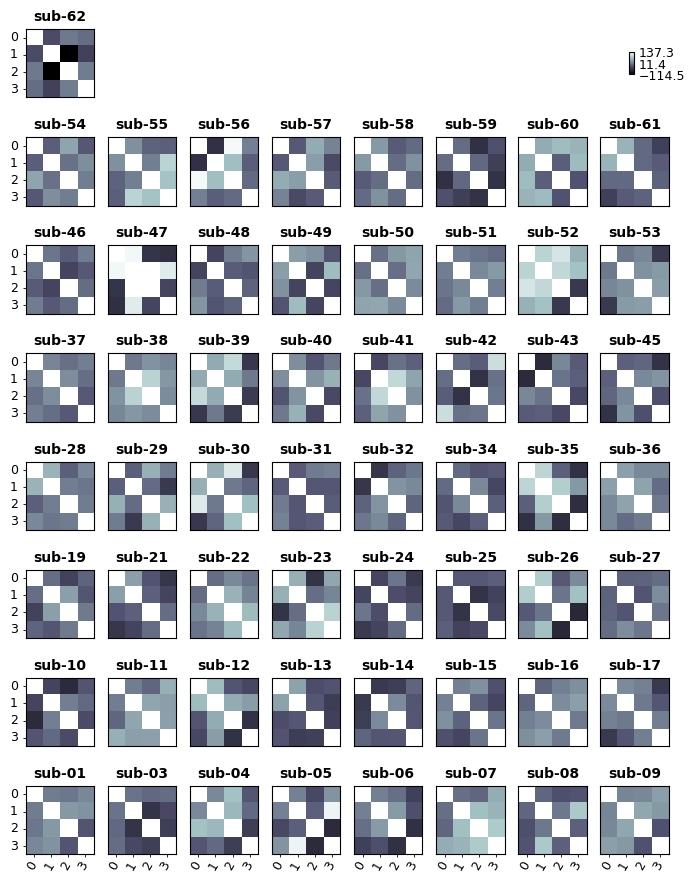

In [11]:
from  rsatoolbox import vis
vis.show_rdm(rdms, rdm_descriptor='subj', show_colorbar='figure', pattern_descriptor='index')

plt.show()

In [12]:
df.loc[df['sub'] == 'sub-03'].head()

,sub,model,region,correlation,performance,mean_rdm_value,32_rdm_value
1,sub-03,affordance,Entorhinal-left,-0.143841,0.814433,-19.657167,-11.595404
58,sub-03,affordance,Entorhinal-right,-0.649641,0.814433,-21.217882,-54.525057


In [13]:
df.loc[df['model'] == 'behav_affordance']

,sub,model,region,correlation,performance,mean_rdm_value,32_rdm_value


/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

0.001786117566673256
0.002241100558791132


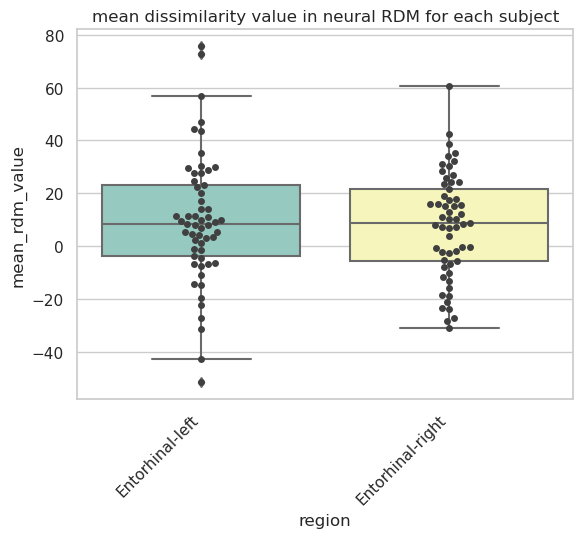

In [14]:
# plot average rdm value as a boxplot

sub_regions = ['Entorhinal-right', 'OFC-bilateral', 'pACC-bilateral','Hippocampus-bilateral']
sub_regions = regions

df_subset = df.loc[(df['model']=='affordance')] # choose one
df_subset = df_subset.loc[(df_subset['region'].isin(sub_regions))]

# choose one

sns.set_theme(style="whitegrid")

ax = sns.boxplot(x="region", y="mean_rdm_value", data=df_subset, palette="Set3")
ax = sns.swarmplot(x="region", y="mean_rdm_value", data=df_subset, color=".25")
# rotate x labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

# t-test against zero and plot p-value above
from scipy.stats import ttest_1samp

for region_ in sub_regions:
    p = ttest_1samp(df_subset.loc[df_subset['region']==region_]['mean_rdm_value'], 0, alternative='greater')[1]
    print(p)


ax.set_title('mean dissimilarity value in neural RDM for each subject')

# shiw
plt.show()


In [16]:
# save df as csv
#df.to_csv('/data/pt_02747/action_hippo/data/derivatives/second_level/rdm_correlations.csv', index=False)

In [12]:
np.max(df['correlation'])

1.3161524331369434

In [13]:
ttest_1samp(region_data[region_data['model'] == 'affordance_magnitude']['correlation'], 0, alternative='greater')

NameError: name 'region_data' is not defined

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

rsa pval: Entorhinal-right affordance 0.018938416229151284
corr and pval: Entorhinal-right affordance 0.06118932301756908 0.6511547208857443


/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

rsa pval: Entorhinal-left affordance 0.6872927133602866
corr and pval: Entorhinal-left affordance -0.18121477620898757 0.17732720590734982


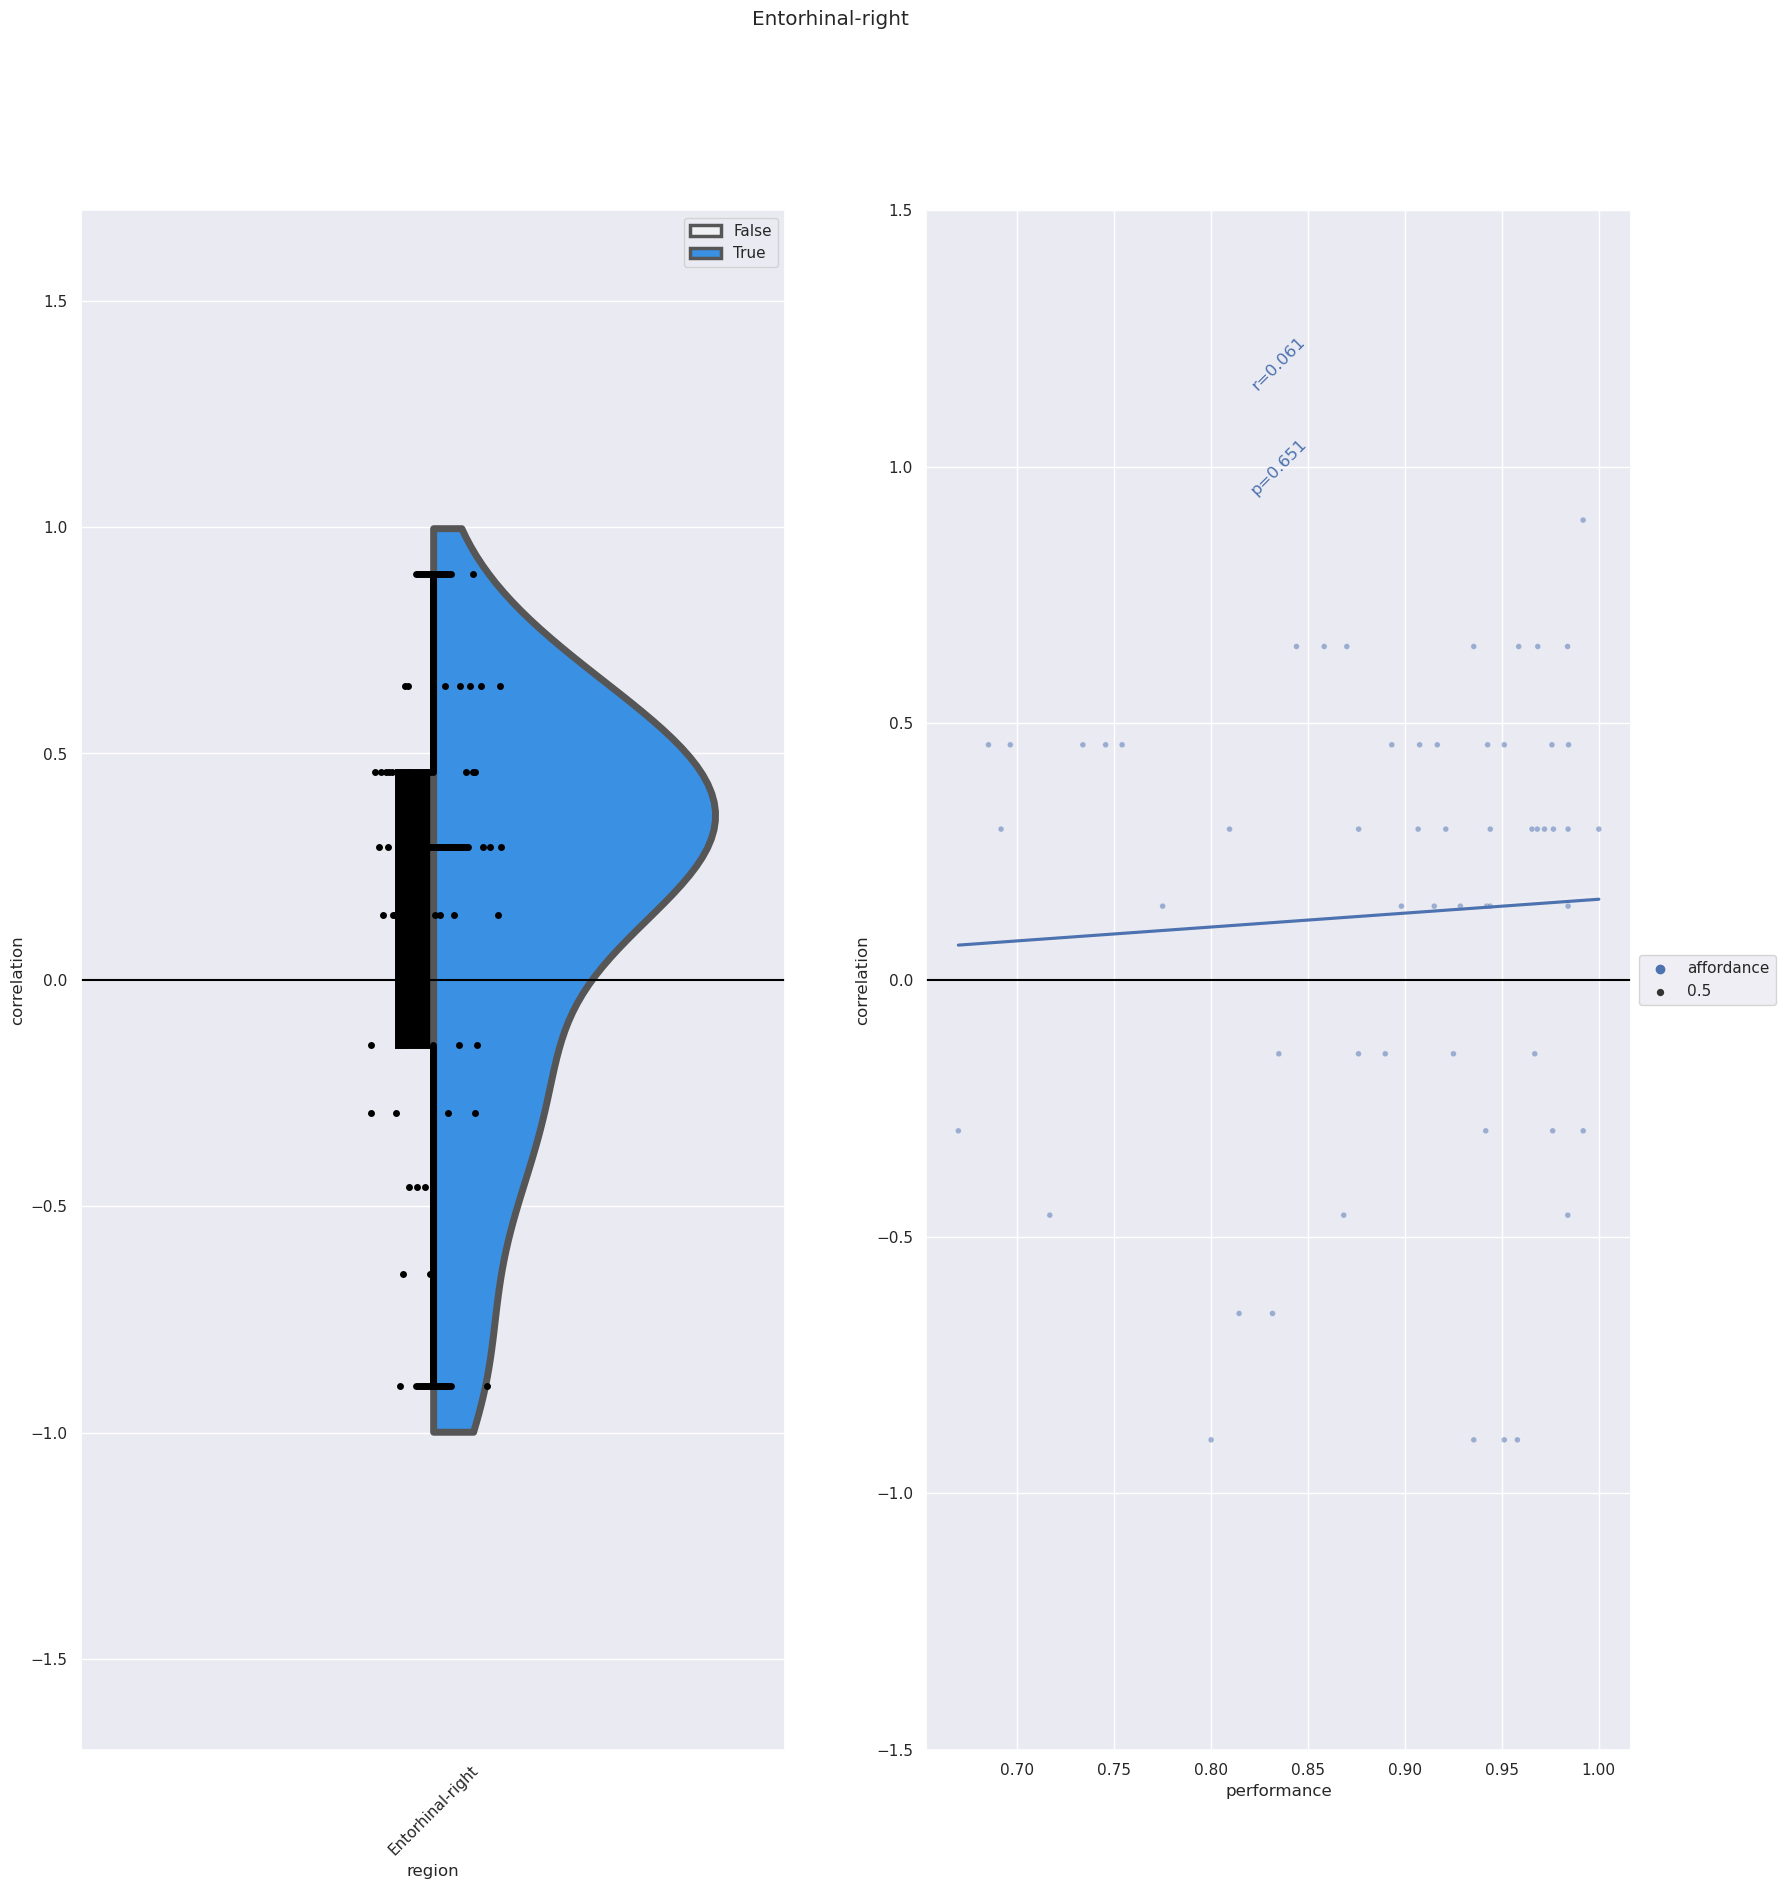

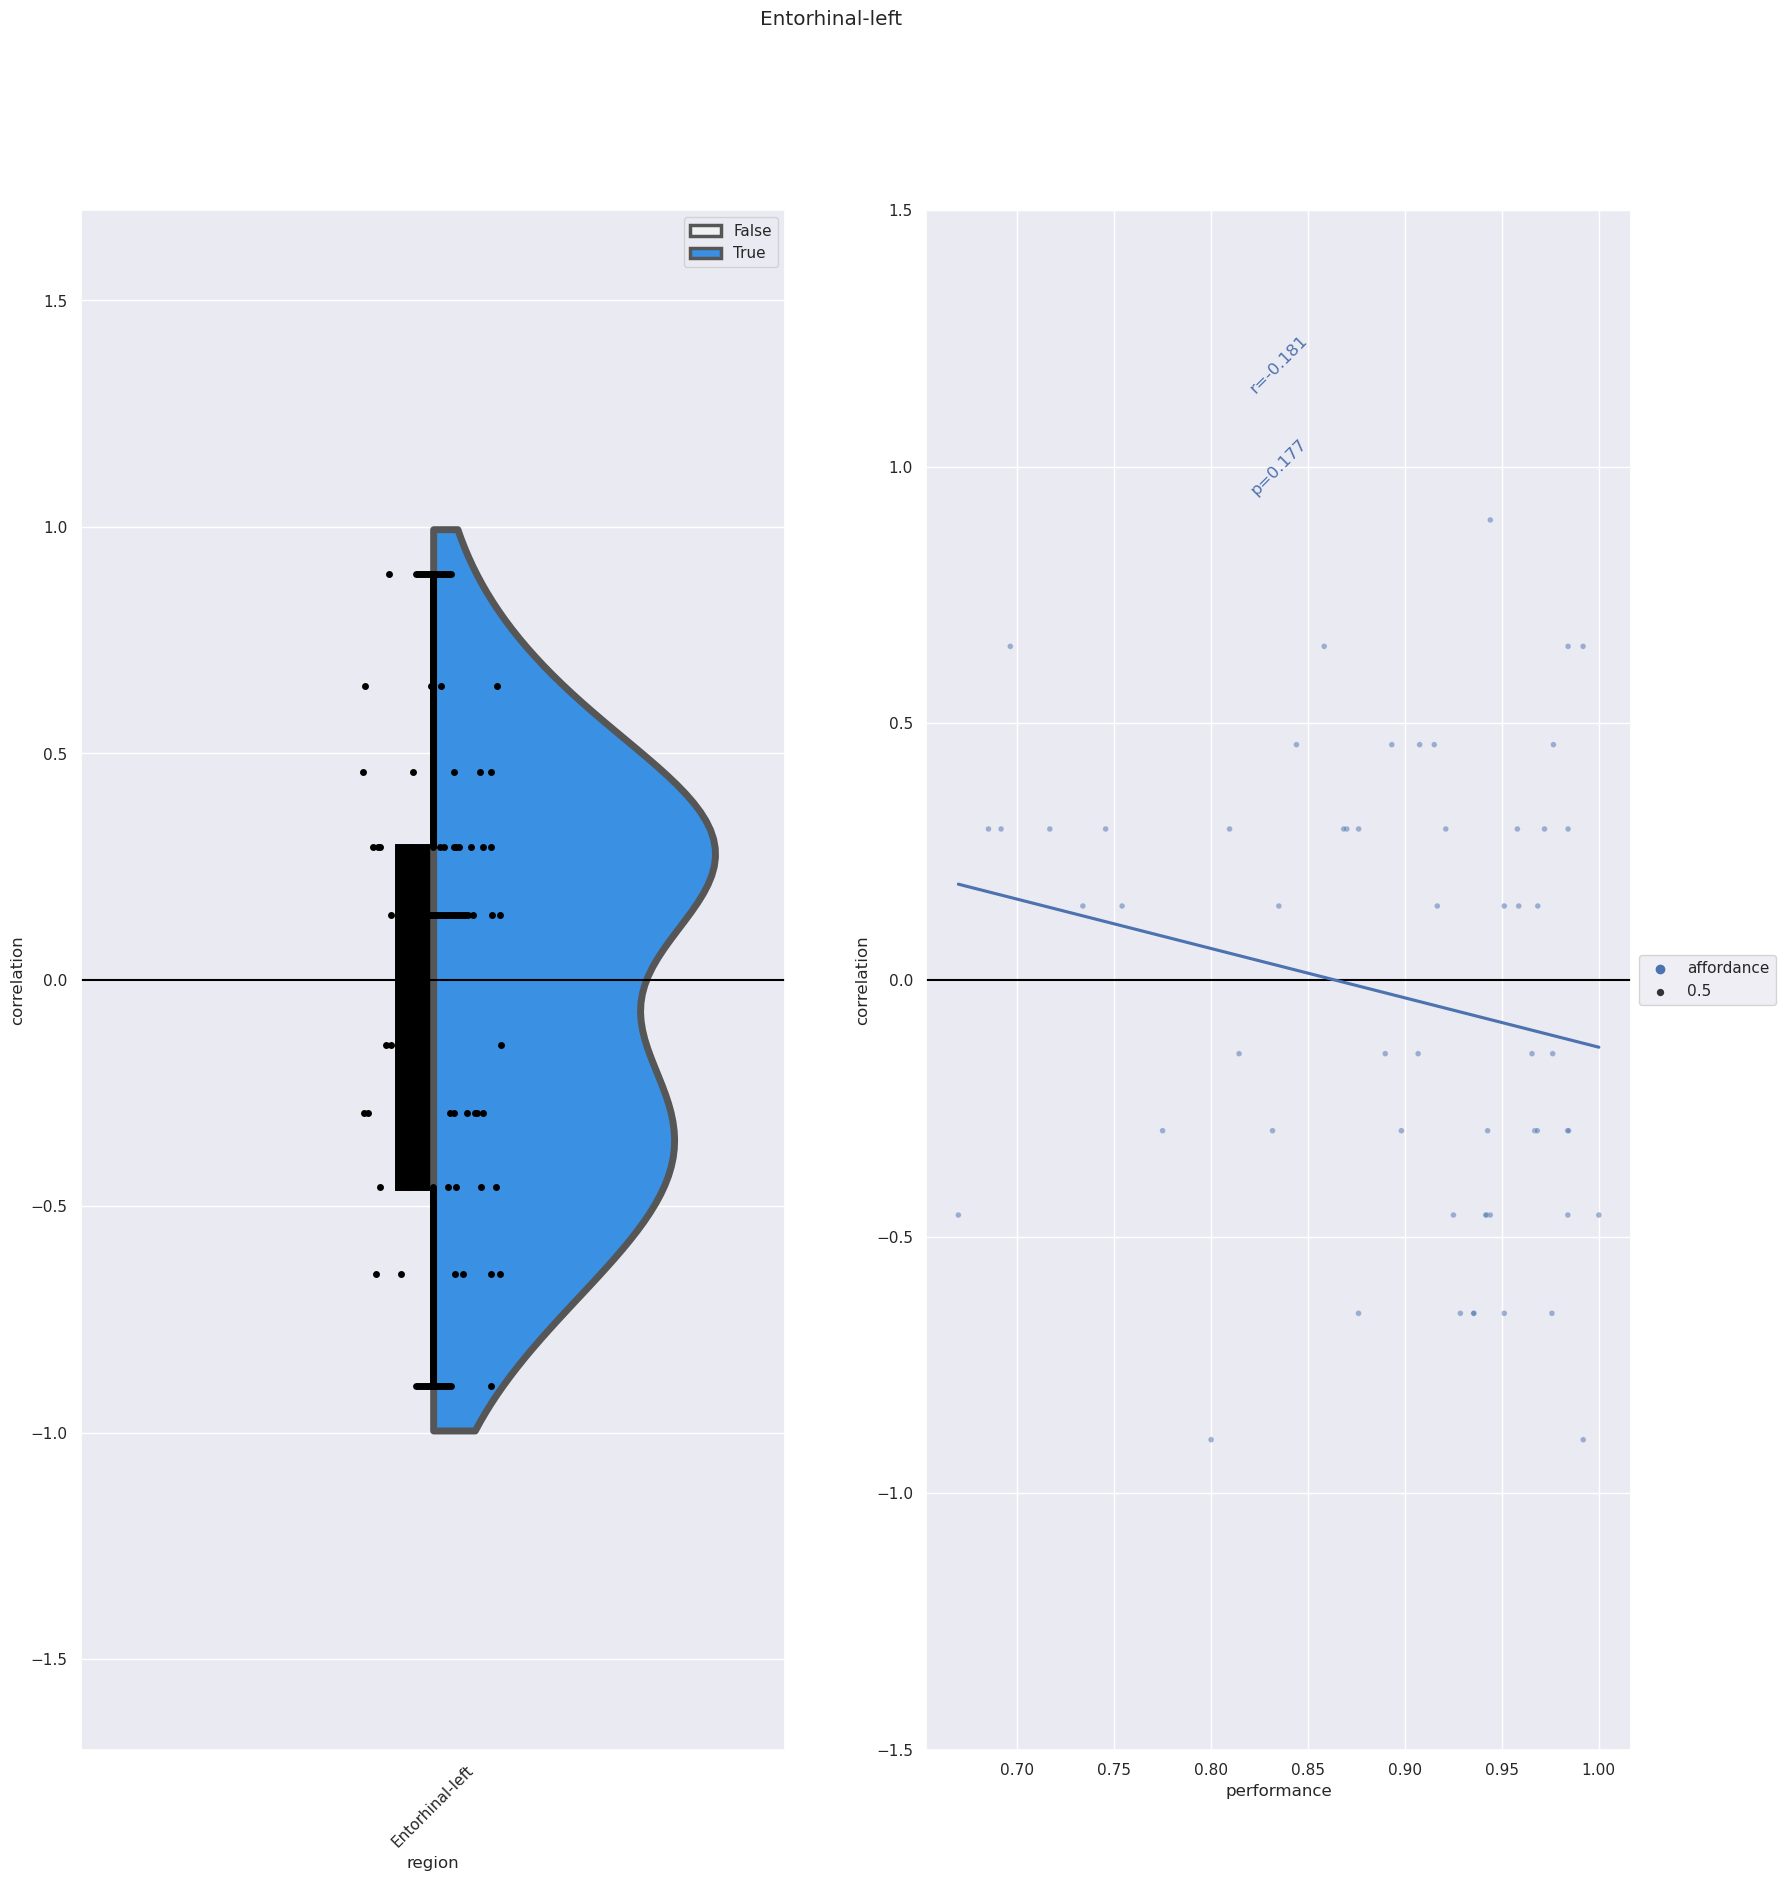

In [7]:

# for each region:

# set sns style to standard
sns.set(style='darkgrid')

# plot violinplot, x = model, y = correlation

# plot scatterplot, x = performance, y = correlation

for region_ in regions:

    region_data = df[df['region'] == region_]
    #region_data = df
    # exclude -inf and inf values for plotting
    #region_data_plot = region_data[~region_data.isin([np.inf, -np.inf]).any(1)]

    region_data_plot = region_data
    # cut amount is 1-max of correlation
    cut_amount = 1 - np.max(np.abs(region_data['correlation']))
    #print(cut_amount)

    fig, ax = plt.subplots(1, 2, figsize=(20, 20))
    
    # new region data df with no points > 1.5
    region_data_plot = region_data[region_data['correlation'] < 1.5]

    sns.violinplot(x='region', y='correlation', data=region_data_plot, ax=ax[0], cut=0.5,
                   hue=True, hue_order=[False, True], split=True, positions =5.5, native_scale=True, linewidth=5,
                   color='dodgerblue')

    # add points to plot on left of violinplot

    sns.stripplot(x='region', y='correlation', data=region_data_plot, ax=ax[0], color='black', jitter=True, dodge=True)
                  # move points to left side of violinplot

    # add boxplot on left of violinplot

    sns.boxplot(x='region', y='correlation', data=region_data_plot, ax=ax[0], color='black', width=0.1, linewidth=5)

                    

    # add a horizontal line at 0
    ax[0].axhline(0, 
                  #ls='--', 
                  color='black')

    # max and min are -1.2 and 1.2
    #ax[0].set_ylim(-np.sqrt((57-3) / 1.06) * np.arctanh(0.99), np.sqrt((57-3) / 1.06) * np.arctanh(0.99))
    ax[0].set_ylim(-1.7, 1.7)

    # annotate with p values for ttest >0 (one sample ttest)
    for i in range(len(models)):
        p = ttest_1samp(region_data[region_data['model'] == models[i]]['correlation'], 0, alternative='greater')[1]
        ax[0].annotate(f"p={p:.3f}", xy=(i, 2.5), ha='center', va='center')
        print('rsa pval:', region_, models[i], p)

    # rortate x labels
    for tick in ax[0].get_xticklabels():
        tick.set_rotation(45)
    

    sns.scatterplot(x='performance', y='correlation', hue='model',data=region_data, ax=ax[1], alpha=0.5, size=0.5)
    # make dots a bit transparent and smaller
    ax[1].axhline(0, 
                  # ls='--',
                  color='black')
    ax[1].set_ylim(-1.5, 1.5)
    # add line of best fit for each model
    count_x = 1
    # len x is number of models
    len_x = len(models)
    
    for model_ in models:
        # color is same as scatterplot
        sns.regplot(x='performance', y='correlation', data=region_data_plot[region_data_plot['model'] == model_], ax=ax[1], scatter=False, color=sns.color_palette()[models.index(model_)], ci=0)
        # calculate correlation and p val using pearson
        corr, p = spearmanr(region_data[region_data['model'] == model_]['performance'], region_data[region_data['model'] == model_]['correlation'])
        print('corr and pval:', region_, model_, corr, p)
        # add text to plot in legends at top, shifted for each model
        # x coord is a quarter of the way along the x axis
        # get max and min of x axis
        x_min, x_max = ax[1].get_xlim()
        # get x coords of each model
        x_coords = np.linspace(x_min, x_max, len_x+2)
        # get x coord of current model
        x_coord = x_coords[count_x]
        

        ax[1].annotate(f"r={corr:.3f}", xy=(x_coord, 1.2), ha='center', va='center', color=sns.color_palette()[models.index(model_)], rotation=45)
        ax[1].annotate(f"p={p:.3f}", xy=(x_coord, 1), ha='center', va='center', color=sns.color_palette()[models.index(model_)], rotation=45)

        count_x += 1
    

    # move scatter plot legend to rght of plot and rotate text by 45 degrees
    ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

    
    plt.suptitle(region_)
    #plt.show()

    # save
    #fig.savefig(f'/data/pt_02747/action_hippo/figures/rdm_correlations_{region_}_subs-{len(subs)}{append_str}.png', dpi=300, bbox_inches='tight')

In [38]:
df.head()

,sub,model,region,correlation,performance,mean_rdm_value,32_rdm_value
0,sub-01,affordance,Entorhinal-right,0.293893,0.976562,15.092949,36.606171
1,sub-03,affordance,Entorhinal-right,-0.649641,0.814433,-21.217882,-54.525057
2,sub-04,affordance,Entorhinal-right,0.458145,0.942623,15.074728,62.436445
3,sub-05,affordance,Entorhinal-right,-0.293893,0.976190,10.867472,-11.016491
4,sub-06,affordance,Entorhinal-right,0.649641,0.935484,-11.479033,38.871247


In [16]:
# check difference between models using paired ttest for each region
# for each region, do a paired ttest between affordance and affordance_magnitude
# for each region, do a paired ttest between affordance and link_distance
# for each region, do a paired ttest between affordance_magnitude and link_distance

from scipy.stats import ttest_rel

for region in df['region'].unique():
    print(region)
    # get data for region
    region_data = df[df['region'] == region]

    # for each model, do a paired ttest with affordance
    for model in models:
        print(model)
        # do ttest
        t, p = ttest_rel(region_data[region_data['model'] == 'affordance']['correlation'], region_data[region_data['model'] == model]['correlation'])
        print(p)


Entorhinal-right
affordance
nan
affordance_magnitude
0.030036595874759545
link_distance
0.045211433062393995
pACC-bilateral
affordance
nan
affordance_magnitude
0.19290100690344308
link_distance
0.5216107351856822
Hippocampus-bilateral
affordance
nan
affordance_magnitude
0.44131714212919837
link_distance
0.15889169776166942
OFC-bilateral
affordance
nan
affordance_magnitude
0.4826538952887519
link_distance
0.10803737118338393
7A-bilateral
affordance
nan
affordance_magnitude
0.4987000196361082
link_distance
0.056136078557010256


In [29]:
ec_df = df.loc[(df['region'] == 'rel5Entorhinal-bilateral') & (df['model'] == 'affordance')]
len(ec_df)

0

In [30]:
corrs = list(ec_df['correlation'])

# exclude nans
corrs = [corr for corr in corrs if not np.isnan(corr)]
len(corrs)

0

In [31]:
# ttest against zero
ttest_1samp(corrs, 0, alternative='greater')[1]

/data/hu_eperon/.local/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/data/hu_eperon/.local/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


nan

In [32]:
a = 3.6745997395515694e-05
# print as normal number
print(f'{a:.6f}')


0.000037


In [33]:
len(list(ec_df['sub']))

0

In [34]:
subs

['sub-01',
 'sub-03',
 'sub-04',
 'sub-05',
 'sub-06',
 'sub-07',
 'sub-08',
 'sub-09',
 'sub-10',
 'sub-11',
 'sub-12',
 'sub-13',
 'sub-14',
 'sub-15',
 'sub-16',
 'sub-17',
 'sub-19',
 'sub-21',
 'sub-22',
 'sub-23',
 'sub-24',
 'sub-25',
 'sub-26',
 'sub-27',
 'sub-28',
 'sub-29',
 'sub-30',
 'sub-31',
 'sub-32',
 'sub-34',
 'sub-35',
 'sub-36',
 'sub-37',
 'sub-38',
 'sub-39',
 'sub-40',
 'sub-41',
 'sub-42',
 'sub-43',
 'sub-45',
 'sub-46',
 'sub-47',
 'sub-48',
 'sub-49',
 'sub-50',
 'sub-51',
 'sub-52',
 'sub-53',
 'sub-54',
 'sub-55',
 'sub-56',
 'sub-57',
 'sub-58',
 'sub-59',
 'sub-60',
 'sub-61',
 'sub-62']

In [22]:
rdms

rsatoolbox.rdm.RDMs(
dissimilarity_measure = 
None
dissimilarities = 
[[  99.50339575  194.16447734   25.51002936  152.18675372   50.785399
   166.94603853]
 [ 110.57071036  130.79134685   75.71162145   97.16124679   22.54358823
    29.75681344]
 [  60.23959867   80.46667101   46.62416257  103.75857104   46.14289901
    34.04714681]
 [ 161.29573912  186.59829437  176.75133245    8.87514084  136.43056503
   101.07836349]
 [  34.56478987   33.73417764   -9.61915194  141.05505455   94.62581084
    49.70402505]
 [ 157.92657217  189.13088489  148.89300971  125.04799555  183.44119401
   256.07942415]
 [  43.53691527   21.7428459    46.87203404  169.66604131  202.45091728
    51.46212488]
 [  86.15041716   43.98734709  -92.86558844  235.21760542  133.00958617
    -6.46109601]
 [  82.8428878    60.21066276   18.13627705   71.00660548  200.67808013
   121.69269863]
 [  84.08726082   51.6781297    94.25145434  -28.26795765  136.00582695
   116.53278087]
 [ 160.90745417  165.80607944   87.0080443

In [23]:
rdms.dissimilarities[0]

array([ 99.50339575, 194.16447734,  25.51002936, 152.18675372,
        50.785399  , 166.94603853])

In [37]:
# average each dissimilarity matrix
avg_dist = []
for i in range(len(rdms.dissimilarities)):
    avg_dist.append(rdms.dissimilarities[i])

# make into array
avg_dist = np.array(avg_dist)

# average across subjects
avg_dist = np.mean(avg_dist, axis=0)

avg_dist

array([11.4063277 , 11.7830611 ,  4.65831256,  9.65649162, 13.63786973,
        6.01688708])

# CODE TO COMPARE MODELS AT SAME TIME

In [34]:
rdms

rsatoolbox.rdm.RDMs(
dissimilarity_measure = 
None
dissimilarities = 
[[-62.87515109  26.77474373 -24.53039662  52.20088203  14.37310926
   62.58991943]
 [ -0.3459796  -49.80737093  -7.14892511 -11.59540373   1.63813816
  -50.68345916]
 [-54.09042685  19.40016907  20.6110009  -12.33080564  74.14720813
  -69.60605794]
 [-69.44519774  52.23382864  28.9266318  -12.19357216 -16.7574721
   43.0038248 ]
 [ 44.03031676  27.85913876  30.54699303  16.47141118  24.16467984
   24.01667157]
 [ 28.70733306 110.94533938 117.27985734  65.90004624 112.87937336
   18.35655647]
 [ -0.42940163   9.26042193  -3.30056226  45.05036853  54.16190097
   16.09385165]
 [ -7.97096285   9.12003866  29.18824079 -41.20503935  59.88555454
   54.29267189]
 [ 22.83769064 -36.14369661  -3.8247086   66.94544934  -6.84457944
  -14.33344751]
 [ -2.32491358  81.82781145  99.89122336  14.38145103  30.30540529
   57.51332675]
 [ 15.97790057 -14.97882726  18.77238921 -36.64809936  60.60072502
   16.85636046]
 [-60.58131566  66

In [35]:
model_name = ['affordance_magnitude', 'link_distance']
rdm_link = rsatoolbox.rdm.RDMs(np.array([
                                                [[0,2,1,1],
                                                [2,0,1,1],
                                                [1,1,0,2],
                                                [1,1,2,0]]]),
                                                
                            dissimilarity_measure='count',
                            descriptors={'n_rdm': 1}
                        )

rdm_aff_mag = rsatoolbox.rdm.RDMs(np.array([[[0,1,1,0],
                                                [1,0,0,1],
                                                [1,0,0,1],
                                                [0,1,1,0]]]),
                                                
                            dissimilarity_measure='count',
                            descriptors={'n_rdm': 1}
                        )




rdm_aff = rsatoolbox.rdm.RDMs(np.array([[[0,1,1,0],
                                                [1,0,2,1],
                                                [1,2,0,1],
                                                [0,1,1,0]]]),
                                                
                            dissimilarity_measure='count',
                            descriptors={'n_rdm': 1}
                        )


# create model as fixed model for evaluation
model_aff_mag = rsatoolbox.model.ModelFixed('affordance_magnitude', rdm_aff_mag)
model_aff_mag.n_rdm = 1

model_link = rsatoolbox.model.ModelFixed('link_distance', rdm_link)
model_link.n_rdm = 1

model_aff = rsatoolbox.model.ModelFixed('affordance', rdm_aff)
model_aff.n_rdm = 1

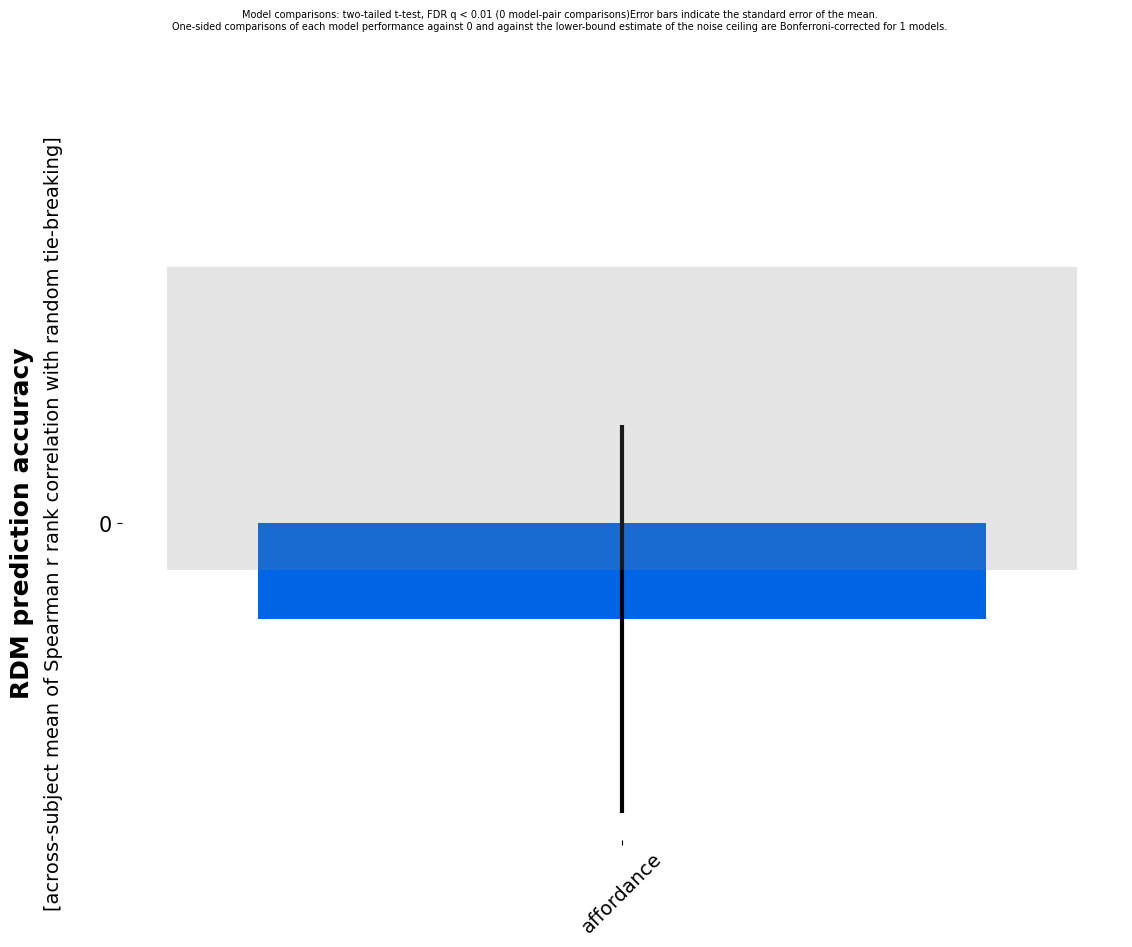

In [36]:

results_corr = rsatoolbox.inference.eval_fixed([model_aff], rdms, method='rho-a')

results = fisher_transform_results(results_corr)

ax = rsatoolbox.vis.plot_model_comparison(results)   #, test_type='ranksum')
plt.rc('ytick', labelsize=15)
plt.rc('xtick', labelsize=15)

plt.show()



In [18]:
print(results.summary(test_type='t-test'))


Results for running fixed evaluation for rho-a on 1 models:

Model      |   Eval ± SEM   | p (against 0) | p (against NC) |
--------------------------------------------------------------
affordance |  0.128 ± 0.060 |        0.019  |         0.246  |

p-values are based on uncorrected t-tests


In [72]:
aff_corrs = results.evaluations[0][0]
aff_mag_corrs = results.evaluations[0][1]
link_corrs = results.evaluations[0][2]


# =============================================================================

from scipy.stats import ttest_rel
print('affordance vs affordance magnitude')
print(ttest_rel(aff_corrs, aff_mag_corrs))
print('affordance vs link distance')
print(ttest_rel(aff_corrs, link_corrs))
print('affordance magnitude vs link distance')
print(ttest_rel(aff_mag_corrs, link_corrs))


affordance vs affordance magnitude
TtestResult(statistic=2.307440182831507, pvalue=0.024750065574405813, df=56)
affordance vs link distance
TtestResult(statistic=2.1708688222965318, pvalue=0.03419564656842575, df=56)
affordance magnitude vs link distance
TtestResult(statistic=-0.09034882039006181, pvalue=0.9283324110967008, df=56)


In [29]:
print(results.test_pairwise(test_type='t-test'))

[[1.00000000e+00 4.01454337e-01 3.30064122e-01]
 [4.01454337e-01 1.00000000e+00 5.32196586e-04]
 [3.30064122e-01 5.32196586e-04 1.00000000e+00]]


### Function to z-transform correlation scores

In [42]:

import numpy as np
from rsatoolbox.util.inference_util import extract_variances
from rsatoolbox.inference.evaluate import boot_noise_ceiling
from rsatoolbox.inference.evaluate import Result



def fisher_transform_results(result_corr):

    """
    Take results module and fisher z-transform evaluations and noise ceiling.

    This is conventionally used to approximate a normal distribution before running t-tests.

    Args:
    
    Results: Results module
        Results module containing evaluation and noise ceiling data.

    """

    evals_to_transform = result_corr.evaluations
    noise_ceil_to_transform = result_corr.noise_ceiling
    # check for values of 0 or 1 - these will generate +/-np.inf after transformation
    # replace with 0.9999 or 0.0001
    evals_to_transform[evals_to_transform == -1] = -0.9999
    evals_to_transform[evals_to_transform == 1] = 0.9999
    noise_ceil_to_transform[noise_ceil_to_transform == -1] = -0.9999
    noise_ceil_to_transform[noise_ceil_to_transform == 1] = 0.9999

    # fisher transform using arctanh
    evaluations_ztrans = np.arctanh(evals_to_transform)
    noise_ceil_ztrans = np.arctanh(noise_ceil_to_transform)

    # variances have changed; deal with this
    if result_corr.n_rdm > 1:
        variances = np.cov(evaluations_ztrans[0], ddof=0) \
            / evaluations_ztrans.shape[-1]
        dof = evaluations_ztrans.shape[-1] - 1
    else:
        variances = None
        dof = 0

    result_ztrans = Result(result_corr.models, evaluations_ztrans, method=result_corr.method,
                    cv_method='fixed', noise_ceiling=noise_ceil_ztrans,
                    variances=variances, dof=dof, n_rdm=result_corr.n_rdm,
                    n_pattern=None)
    
    # add 'transform' string to reflect transformation
    result_ztrans.transform = "Fisher z-transformed"
    
    return result_ztrans

# CODE TO USE DIAGONAL

In [43]:
rdms

rsatoolbox.rdm.RDMs(
dissimilarity_measure = 
None
dissimilarities = 
[[-1.42575001e+01 -1.17119458e+01  9.85519038e+00 -2.08439801e+01
  -7.18561297e+00 -6.77640965e+00]
 [ 1.32954042e+01  1.84849593e+01 -1.65481526e+01  1.39820314e+01
   8.00035552e+00  2.61626474e+01]
 [ 1.23922637e+01  5.39135946e+01 -5.87768482e+00  6.25682472e+01
   2.02291025e+01  3.91529084e-01]
 [-1.91756897e+00  2.23511020e+01  3.83607184e+01 -6.33510513e+00
   2.22867360e+01 -4.87826205e-01]
 [-2.16319689e+01 -5.31721745e+00  5.88019197e+00  1.54323286e+00
   1.31862803e+01 -1.14401791e+01]
 [ 9.02871636e+00  7.24458197e+00  5.91946091e+00  1.52703533e+01
   3.69465626e+01  3.21643093e+01]
 [ 5.19755656e+00 -2.12926760e+01  1.19320186e+00 -4.48500136e+00
   1.14450249e+01 -8.58886332e-01]
 [-5.28410630e+00 -2.59094465e+00  3.07654729e+01  1.82940589e+00
   1.59532311e+01 -2.17992904e+01]
 [-1.26858110e-01 -6.13625231e+00 -2.93164658e+00  1.94559300e+01
   1.23915989e+01 -1.25874450e+01]
 [-8.05387543e-01 -1.